**QUESTION:**

Use the same dataset that is used for building logistic regression
classifier model, experiment chi-square and mutual information based
feature selection on the data set. Build the model with all features
and subset of features obtained using chi-square and mutual
information and compare the performances and provide your
inferences.

**KAGGLE DATASET:** https://www.kaggle.com/datasets/taweilo/mba-admission-dataset

In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df=pd.read_csv("/content/drive/MyDrive/MBA.csv")

In [6]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [7]:
df.shape

(6194, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [9]:
df.isnull().sum() #checking for Null values

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,1842
gmat,0
work_exp,0
work_industry,0
admission,5194


In [10]:
df['race'].value_counts()

,count
race,
White,1456
Asian,1147
Black,916
Hispanic,596
Other,237


In [11]:
mo = df['race'].mode()
mo

,race
0,White


In [12]:
df['race'] = df['race'].fillna(df['race'].mode()[0]) #mode imputation of Null values

In [13]:
df['race'].value_counts()

,count
race,
White,3298
Asian,1147
Black,916
Hispanic,596
Other,237


In [14]:
df['race'].isnull().sum()

0

In [15]:
df

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,White,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,NaN
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,NaN
6191,6192,Female,True,3.22,Business,White,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,White,590.0,5.0,Other,NaN


In [16]:
df["admission"].value_counts()

,count
admission,
Admit,900
Waitlist,100


In [17]:
df["admission"].isnull().sum()

5194

In [18]:
df['admission'] = df['admission'].fillna("Not-Admit") #updating NA values to Not-Admit

In [19]:
df["admission"].value_counts()

,count
admission,
Not-Admit,5194
Admit,900
Waitlist,100


In [20]:
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,Not-Admit
2,3,Female,True,3.30,Business,White,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,Not-Admit
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,Not-Admit


In [21]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [22]:
x=df.drop("admission",axis=1)

In [23]:
x

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management
2,3,Female,True,3.30,Business,White,710.0,5.0,Technology
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting
...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting
6191,6192,Female,True,3.22,Business,White,680.0,5.0,Health Care
6192,6193,Male,True,3.36,Business,White,590.0,5.0,Other


In [24]:
y=df["admission"]

In [25]:
y

,admission
0,Admit
1,Not-Admit
2,Admit
3,Not-Admit
4,Not-Admit
...,...
6189,Not-Admit
6190,Not-Admit
6191,Admit
6192,Not-Admit


In [26]:
oe=OrdinalEncoder()
oe.fit(x)  #first fit the encoding on the training data set
X_enc=oe.transform(x)

In [27]:
X_enc

array([[0.000e+00, 0.000e+00, 0.000e+00, ..., 5.000e+00, 2.000e+00,
        3.000e+00],
       [1.000e+00, 1.000e+00, 0.000e+00, ..., 1.100e+01, 4.000e+00,
        6.000e+00],
       [2.000e+00, 0.000e+00, 1.000e+00, ..., 1.400e+01, 4.000e+00,
        1.300e+01],
       ...,
       [6.191e+03, 0.000e+00, 1.000e+00, ..., 1.100e+01, 4.000e+00,
        4.000e+00],
       [6.192e+03, 1.000e+00, 1.000e+00, ..., 2.000e+00, 4.000e+00,
        9.000e+00],
       [6.193e+03, 1.000e+00, 0.000e+00, ..., 8.000e+00, 3.000e+00,
        1.000e+00]])

In [28]:
dict={"Not-Admit":-1,"Admit":1,"Waitlist":0 }
y=y.map(dict) #manual encoding using Dictionary

In [29]:
y

,admission
0,1
1,-1
2,1
3,-1
4,-1
...,...
6189,-1
6190,-1
6191,1
6192,-1


In [30]:
y.value_counts()

,count
admission,
-1,5194
1,900
0,100


In [31]:
Y_enc=y.values

In [32]:
Y_enc

array([ 1, -1,  1, ...,  1, -1, -1])

In [33]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split

In [34]:
#split the data set into train and test set
X_train, X_test, Y_train, Y_test=train_test_split(X_enc, Y_enc, test_size=0.33, random_state=1)
#print the shape
print("Train", X_train.shape,Y_train.shape)
print("Test",X_test.shape, Y_test.shape)

Train (4149, 9) (4149,)
Test (2045, 9) (2045,)


**CHI-SQUARE**

In [35]:
def select_features(X_train, Y_train, X_test):
    fs=SelectKBest(score_func=chi2, k='all')
    fs.fit(X_train, Y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs, X_test_fs, fs


In [36]:
#calling feature selection function
X_train_fs, X_test_fs, fs=select_features(X_train, Y_train, X_test)

In [37]:
fs.scores_

array([6.34412549e+04, 2.64843731e+01, 4.92712189e-01, 1.53445269e+03,
       2.24581824e+00, 4.79158394e+00, 1.60637145e+03, 5.04389677e-01,
       1.49669856e+00])

In [38]:
import matplotlib.pyplot as plt

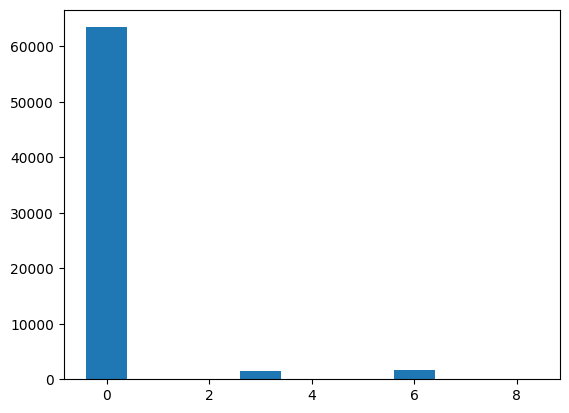

In [39]:
#plot the scores
plt.bar([i for i in range (len(fs.scores_))],fs.scores_)
plt.show()

Here

* 0-Application Number
* 3-GPA
* 6-GMAT

are the most relevant feratures

In [40]:
from sklearn.feature_selection import mutual_info_classif

**MUTUAL INFORMATION FEATURE SELECTION**

In [41]:
def select_features_2(X_train, Y_train, X_test):
    fs=SelectKBest(score_func=mutual_info_classif, k='all')
    fs.fit(X_train, Y_train)
    X_train_fs_2=fs.transform(X_train)
    X_test_fs_2=fs.transform(X_test)
    return X_train_fs_2, X_test_fs_2, fs

In [42]:
#calling feature selection function
X_train_fs_2, X_test_fs_2, fs=select_features_2(X_train, Y_train, X_test)

In [43]:
fs.scores_

array([2.41468600e-02, 4.68249447e-03, 0.00000000e+00, 4.25534526e-02,
       0.00000000e+00, 7.80950316e-03, 7.97828626e-02, 3.14188447e-05,
       0.00000000e+00])

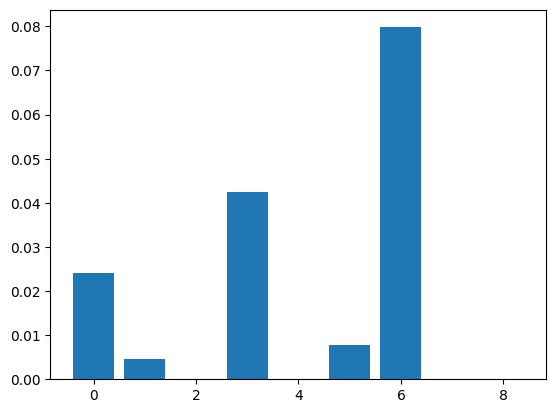

In [44]:
#plot the scores
plt.bar([i for i in range (len(fs.scores_))],fs.scores_)
plt.show()

**MODEL BUILDING**

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [46]:
model=LogisticRegression(solver='lbfgs')
model.fit(X_train, Y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_pred=model.predict(X_test)

In [48]:
accuracy=accuracy_score(Y_test, y_pred)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 82.54


In [49]:
model1=LogisticRegression()
#fit the model
model1.fit(X_train_fs, Y_train)
#evaluate the model
yhat=model1.predict(X_test_fs)
#evaluate the performance
accuracy=accuracy_score(Y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 82.54


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
model2=LogisticRegression(solver='lbfgs')
#fit the model
model2.fit(X_train_fs_2, Y_train)
#evaluate the model
yhat=model2.predict(X_test_fs_2)
#evaluate the performance
accuracy=accuracy_score(Y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 82.54


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8
0,1613.0,0.0,0.0,51.0,1.0,4.0,7.0,3.0,9.0
1,1603.0,1.0,1.0,26.0,2.0,4.0,4.0,4.0,13.0
2,4265.0,1.0,1.0,41.0,1.0,4.0,8.0,4.0,1.0
3,3227.0,0.0,1.0,69.0,0.0,4.0,13.0,3.0,5.0
4,4065.0,0.0,0.0,48.0,0.0,3.0,4.0,5.0,9.0
...,...,...,...,...,...,...,...,...,...
4144,905.0,1.0,0.0,41.0,2.0,2.0,5.0,5.0,9.0
4145,5192.0,1.0,1.0,49.0,0.0,4.0,6.0,4.0,8.0
4146,3980.0,0.0,0.0,64.0,1.0,2.0,14.0,5.0,1.0
4147,235.0,1.0,0.0,27.0,2.0,1.0,2.0,4.0,1.0


In [52]:
df

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,Not-Admit
2,3,Female,True,3.30,Business,White,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,Not-Admit
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,Not-Admit
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,Not-Admit
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,Not-Admit
6191,6192,Female,True,3.22,Business,White,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,White,590.0,5.0,Other,Not-Admit


In [53]:
X_enc=pd.DataFrame(X_enc)

In [54]:
X_enc

,0,1,2,3,4,5,6,7,8
0,0.0,0.0,0.0,55.0,0.0,0.0,5.0,2.0,3.0
1,1.0,1.0,0.0,53.0,1.0,1.0,11.0,4.0,6.0
2,2.0,0.0,1.0,55.0,0.0,4.0,14.0,4.0,13.0
3,3.0,1.0,0.0,72.0,2.0,1.0,12.0,5.0,13.0
4,4.0,1.0,0.0,60.0,2.0,2.0,2.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...
6189,6189.0,1.0,0.0,74.0,0.0,4.0,7.0,4.0,9.0
6190,6190.0,1.0,0.0,43.0,2.0,1.0,10.0,3.0,1.0
6191,6191.0,0.0,1.0,47.0,0.0,4.0,11.0,4.0,4.0
6192,6192.0,1.0,1.0,61.0,0.0,4.0,2.0,4.0,9.0


**SELECTION FEATURES WHICH HAS HIGH CO-RELATION**

In [55]:
new_X = X_enc.iloc[:, [0,3,6]] #training the model using the columns which has high fs.score values in chi-square and mutual_info_classification

In [56]:
new_X

,0,3,6
0,0.0,55.0,5.0
1,1.0,53.0,11.0
2,2.0,55.0,14.0
3,3.0,72.0,12.0
4,4.0,60.0,2.0
...,...,...,...
6189,6189.0,74.0,7.0
6190,6190.0,43.0,10.0
6191,6191.0,47.0,11.0
6192,6192.0,61.0,2.0


In [57]:
X_train, X_test, Y_train, Y_test=train_test_split(new_X, Y_enc, test_size=0.33, random_state=1)
#print the shape
print("Train", X_train.shape,Y_train.shape)
print("Test",X_test.shape, Y_test.shape)

Train (4149, 3) (4149,)
Test (2045, 3) (2045,)


In [58]:
log=LogisticRegression(solver='lbfgs')
log.fit(X_train, Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [59]:
y_pred1=log.predict(X_test)

In [60]:
accuracy_score(Y_test,y_pred1)

0.8180929095354523

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [62]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=1)
rf_classifier.fit(X_train, Y_train)

RandomForestClassifier(random_state=1)

In [63]:
y_pred_rf = rf_classifier.predict(X_test)

In [64]:
accuracy_rf = accuracy_score(Y_test, y_pred_rf)
print("Random Forest Accuracy: %.2f" % (accuracy_rf * 100))

Random Forest Accuracy: 80.00


**Checking Accuracy with various K-Features**

In [65]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def build_and_evaluate_model(X_train, Y_train, X_test, Y_test, k):
    # Feature selection using SelectKBest with chi2
    fs = SelectKBest(score_func=chi2, k=k)
    fs.fit(X_train, Y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)

    # Initialize and train logistic regression model
    model = LogisticRegression()
    model.fit(X_train_fs, Y_train)

    # Make predictions
    Y_pred = model.predict(X_test_fs)

    # Evaluate the model
    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"Accuracy with {k} best features (Chi-squared):", accuracy)
    print(classification_report(Y_test, Y_pred))
    print(confusion_matrix(Y_test, Y_pred))
    print("-" * 50)

# Build and evaluate models with different numbers of best features
for k in range(1, 8):  # Iterate through 1 to 6 best features
    build_and_evaluate_model(X_train, Y_train, X_test, Y_test, k)


Accuracy with 1 best features (Chi-squared): 0.8347188264058679
              precision    recall  f1-score   support

          -1       0.83      1.00      0.91      1707
           0       0.00      0.00      0.00        31
           1       0.00      0.00      0.00       307

    accuracy                           0.83      2045
   macro avg       0.28      0.33      0.30      2045
weighted avg       0.70      0.83      0.76      2045

[[1707    0    0]
 [  31    0    0]
 [ 307    0    0]]
--------------------------------------------------
Accuracy with 2 best features (Chi-squared): 0.8190709046454768
              precision    recall  f1-score   support

          -1       0.84      0.96      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.09      0.14       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.35      2045
weighted avg       0.75      0.82      0.77      2045

[[16

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/l

Accuracy with 3 best features (Chi-squared): 0.8180929095354523
              precision    recall  f1-score   support

          -1       0.84      0.97      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.07      0.11       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.34      2045
weighted avg       0.75      0.82      0.77      2045

[[1652    9   46]
 [  31    0    0]
 [ 285    1   21]]
--------------------------------------------------


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=4 is greater than n_features=3. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/

Accuracy with 4 best features (Chi-squared): 0.8180929095354523
              precision    recall  f1-score   support

          -1       0.84      0.97      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.07      0.11       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.34      2045
weighted avg       0.75      0.82      0.77      2045

[[1652    9   46]
 [  31    0    0]
 [ 285    1   21]]
--------------------------------------------------
Accuracy with 5 best features (Chi-squared): 0.8180929095354523
              precision    recall  f1-score   support

          -1       0.84      0.97      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.07      0.11       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.34      2045
weighted avg       0.75      0.82      0.77      2045

[[16

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=6 is greater than n_features=3. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/

Accuracy with 6 best features (Chi-squared): 0.8180929095354523
              precision    recall  f1-score   support

          -1       0.84      0.97      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.07      0.11       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.34      2045
weighted avg       0.75      0.82      0.77      2045

[[1652    9   46]
 [  31    0    0]
 [ 285    1   21]]
--------------------------------------------------
Accuracy with 7 best features (Chi-squared): 0.8180929095354523
              precision    recall  f1-score   support

          -1       0.84      0.97      0.90      1707
           0       0.00      0.00      0.00        31
           1       0.31      0.07      0.11       307

    accuracy                           0.82      2045
   macro avg       0.38      0.35      0.34      2045
weighted avg       0.75      0.82      0.77      2045

[[16

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
81.80929095354523/82.54 #The Model Predicts nearly 99% only using 3 features obtained from chi-square and mutual_info_classification compared to all the features

0.9911472129094405

**OUTCOME:**

* Based on the above inference, we used Chi square method and mutual Information methods to find the co-relation between the categorical data. We used the method to reduce the no of feature and selected best features for this model and obtained accuracy equal to the original dataset
* Checking Accuracy with various K-Features we found accuracy of 83.47188264058679% with one best feature